# Ethan's Notebook

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point

%matplotlib inline
pd.set_option('display.max_columns', 500)
plt.style.use('fivethirtyeight')

## Load Data

In [2]:
df = pd.read_csv('../data/mortgage_covenant_data.csv', dtype= {'census_tract': 'str'})
display(df.head())
df.info()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,27037060737,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,27141030504,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,27023950400,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,27171100101,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,27159480100,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   object 
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

## Create Hennepin County Dataframe

In [3]:
df_hennepin = df[df['census_tract'].str[:5] == '27053'].copy()
print(df_hennepin.shape)
display(df_hennepin.head())
df_hennepin.info()

(22669, 14)


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
19,2023,27053026822,Race Not Available,6,445000.0,455000.0,NaN,7.625,39.47,100.56,10,0.0,False,NaN
36,2023,27053012102,Race Not Available,6,265000.0,275000.0,NaN,3.250,29.71,98.77,10,68.0,False,Medium (51-100)
68,2023,27053026202,White,1,315000.0,425000.0,NaN,8.250,12.84,159.62,10,2.0,True,Low (1-50)
69,2023,27053027602,White,4,515000.0,NaN,210.0,NaN,11.59,113.96,10,76.0,False,Medium (51-100)
70,2023,27053006800,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 22669 entries, 19 to 100922
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      22669 non-null  int64  
 1   census_tract                       22669 non-null  object 
 2   derived_race                       22669 non-null  object 
 3   action_taken                       22669 non-null  int64  
 4   loan_amount                        22669 non-null  float64
 5   property_value                     19023 non-null  float64
 6   income                             19545 non-null  float64
 7   interest_rate                      18069 non-null  float64
 8   tract_minority_population_percent  22669 non-null  float64
 9   tract_to_msa_income_percentage     22669 non-null  float64
 10  denial_reason-1                    22669 non-null  int64  
 11  covenant_count                     22669 non-null  float6

## Initial Analysis

### Relationship Between Covenant Density and Property Values

In [4]:
df_hennepin['covenant_density'].value_counts(dropna=False)

covenant_density
NaN                 11500
Low (1-50)           4537
Very High (>200)     3140
Medium (51-100)      1772
High (101-200)       1720
Name: count, dtype: int64

Looking at the value counts for covenant_density, it shows that the biggest group is the rows with no listed density value. After that, the Low (1-50) group is the largest named category, while Medium and High have fewer records.

In [5]:
property_by_density = df_hennepin.groupby('covenant_density', dropna=False)['property_value'].agg(['count', 'mean', 'median', 'std']).sort_values(by='median', ascending=False)
display(property_by_density)

,count,mean,median,std
covenant_density,,,,
Very High (>200),2660,506902.255639,385000.0,4.906733e+05
High (101-200),1438,547739.916551,375000.0,1.749168e+06
Medium (51-100),1504,567187.500000,365000.0,1.682592e+06
NaN,9642,501293.300145,365000.0,2.105706e+06
Low (1-50),3779,418831.701508,325000.0,3.404951e+05


Looking at the summary table for property value by covenant density, it shows that the Low (1-50) group has the lowest median home value at $325,000. The other groups have higher medians, with Very High (>200) having the highest median at $385,000, but the averages are affected by some very large outliers.

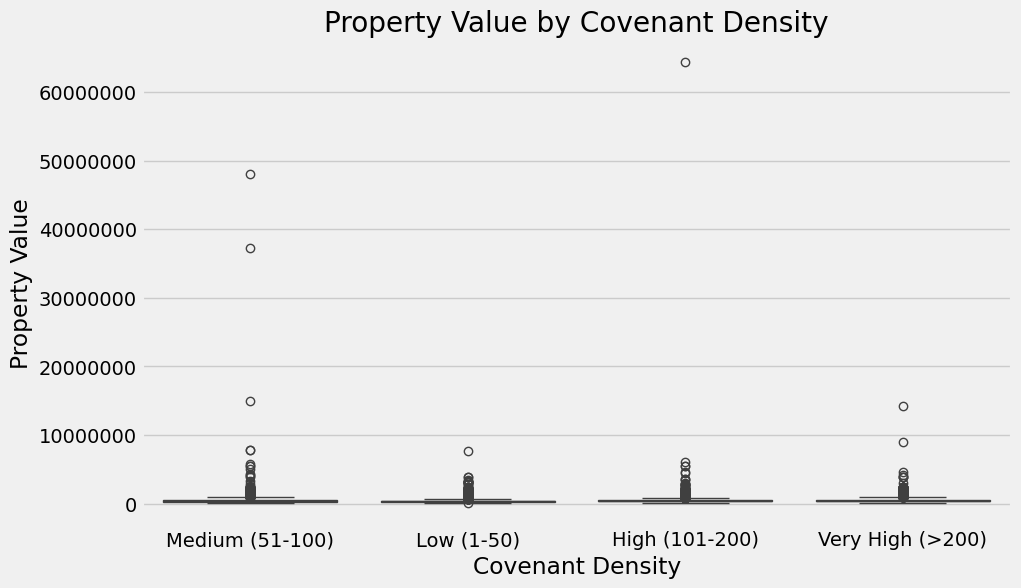

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df_hennepin, x = 'covenant_density', y ='property_value')
plt.title('Property Value by Covenant Density')
plt.xlabel('Covenant Density')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')

Looking at the boxplot for property value by covenant density, it shows that most home values are grouped much lower on the chart, while a small number of very expensive properties stretch far above the rest. It also shows that the middle ranges for the groups are fairly close, but Low (1-50) appears lower than the others.

In [7]:
df_hennepin['has_covenant'] = df_hennepin['covenant_count'] > 0
property_by_covenant = df_hennepin.groupby('has_covenant')['property_value'].agg(['count', 'mean', 'median', 'std'])
display(property_by_covenant)

,count,mean,median,std
has_covenant,,,,
False,9642,501293.300145,365000.0,2.105706e+06
True,9381,487349.429698,355000.0,1.020242e+06


Looking at the summary for has_covenant, it shows that areas without a historical covenant have a slightly higher median property value ($365,000) than areas with a covenant ($355,000). The mean values are also close, but both groups have a wide spread in property values.

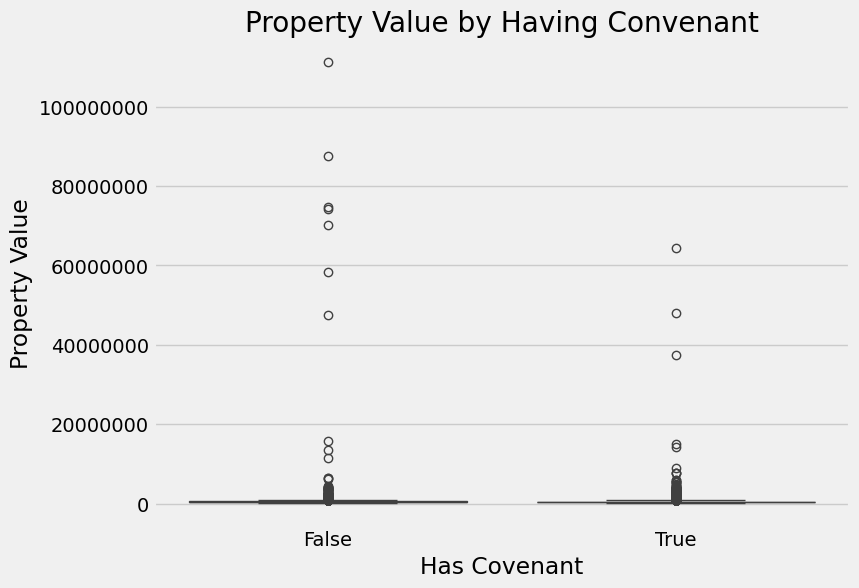

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data = df_hennepin, x ='has_covenant', y = 'property_value')
plt.title('Property Value by Having Convenant')
plt.xlabel('Has Covenant')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')

Looking at the boxplot for having a covenant or not, it shows that both groups have many outliers and a wide range of property values. It also shows that the centers of the two groups are pretty similar, though the non-covenanted group looks a little higher.

**Summary**:
In this analysis, there does seem to be some relationship between covenant history and property values, but it is not a very simple pattern. The Low (1-50) density group stands out with the lowest median property value, while the other density groups are higher and closer to each other. When the data is split into just two groups, non-covenanted areas have a slightly higher median home value than covenanted areas. The graphs also show many extreme outliers, which means a few very large property values can make the averages look bigger than what is normal for most homes. Because of that, the median is more useful here than the mean. Overall, this part suggests that historical covenant patterns may still connect to property values today, but the difference is modest and should be read carefully.

### Modern Mortgage Approval Patterns

In [9]:
approval_rate = df_hennepin['was_approved'].mean()
print(f"Overall approval rate: {round(approval_rate, 2)}")

Overall approval rate: 0.66


Looking at the overall approval rate, it shows that about 66% of the mortgage applications in this Hennepin County data were approved. This gives a starting point for the rest of the approval comparisons.

In [10]:
approval_by_race = df_hennepin.groupby('derived_race')['was_approved'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
approval_by_race.rename(columns={'mean': 'approval_rate'}, inplace=True)
display(approval_by_race)

,count,approval_rate
derived_race,,
Joint,683,0.773060
White,12767,0.764393
Asian,1642,0.702801
Native Hawaiian or Other Pacific Islander,18,0.666667
Black or African American,1760,0.599432
2 or more minority races,42,0.595238
American Indian or Alaska Native,147,0.578231
Race Not Available,5610,0.418895


Looking at approval rate by race, it shows clear differences between groups. Joint and White applicants have the highest approval rates, while Black or African American, American Indian or Alaska Native, and especially Race Not Available have lower approval rates.

In [11]:
approval_by_density = df_hennepin.groupby('covenant_density', dropna=False)['was_approved'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
approval_by_density.rename(columns={'mean': 'approval_rate'}, inplace=True)
display(approval_by_density)

,count,approval_rate
covenant_density,,
High (101-200),1720,0.692442
Very High (>200),3140,0.673885
Medium (51-100),1772,0.670429
Low (1-50),4537,0.661230
NaN,11500,0.649826


Looking at approval rate by covenant density, it shows that the approval rates are fairly close across the groups, but they are not exactly the same. The High (101-200) group has the highest approval rate, while the rows with no covenant density listed have the lowest rate.

(0.0, 1.0)

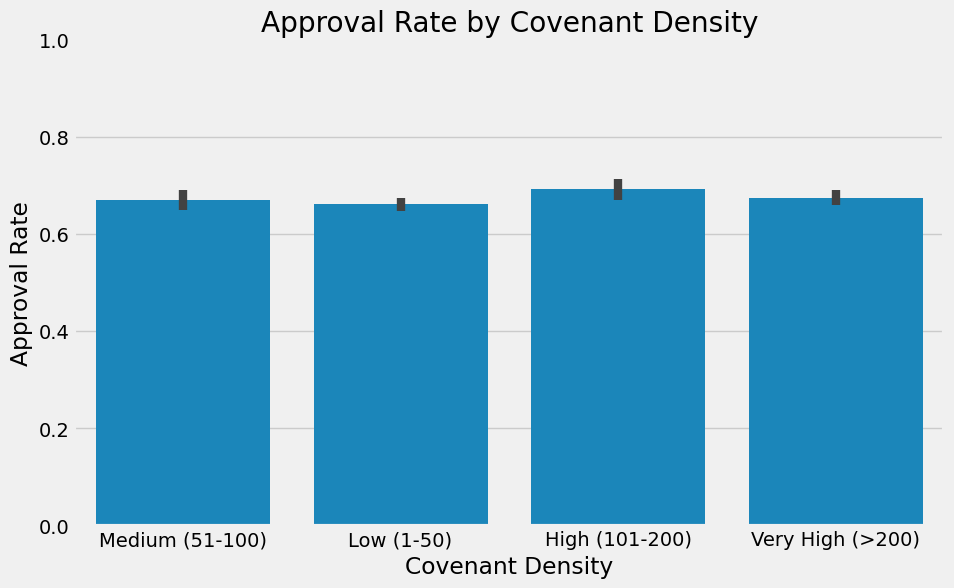

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_hennepin, x = 'covenant_density', y = 'was_approved')
plt.title('Approval Rate by Covenant Density')
plt.xlabel('Covenant Density')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)

Looking at the bar chart for approval rate by covenant density, it shows only small differences between the groups. The bars are all near the same level, which suggests covenant density alone does not create a huge gap in approval rates.

In [13]:
approval_by_covenant = df_hennepin.groupby('has_covenant')['was_approved'].agg(['count', 'mean'])
approval_by_covenant.rename(columns={'mean': 'approval_rate'}, inplace=True)
display(approval_by_covenant)

,count,approval_rate
has_covenant,,
False,11500,0.649826
True,11169,0.671054


Looking at approval rate by whether a tract had a covenant or not, it shows that areas with a historical covenant have a slightly higher approval rate (0.67) than areas without one (0.65). This means the simple two-group comparison does not show lower approval in covenanted areas.

**Summary**:
In this analysis, the strongest pattern is by race, not by covenant density alone. Approval rates are much higher for White and Joint applicants than for several other race groups, and the Race Not Available group is much lower than all the others. By contrast, approval rates by covenant density and by covenant presence are fairly close, with only small differences between groups. In fact, the covenanted areas show a slightly higher approval rate than the non-covenanted areas in this simple comparison. This suggests that modern mortgage approval patterns may be tied more strongly to applicant race than to covenant history by itself, at least in this first look. Still, covenant history may connect to other factors in the data, so this should not be treated as the final answer.

### Potential Proxy Variables for Historical Discrimination

In [14]:
proxy_vars = [
    'property_value', 'income', 'loan_amount',
    'interest_rate', 'tract_minority_population_percent',
    'tract_to_msa_income_percentage', 'covenant_count'
]
corr_df = df_hennepin[proxy_vars].corr()
display(corr_df)

,property_value,income,loan_amount,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,covenant_count
property_value,1.000000,0.555435,0.977107,-0.017676,-0.064815,0.092387,0.007473
income,0.555435,1.000000,0.295732,0.034710,-0.127723,0.167185,0.038840
loan_amount,0.977107,0.295732,1.000000,-0.005169,-0.075171,0.102961,0.008894
interest_rate,-0.017676,0.034710,-0.005169,1.000000,-0.034041,0.004742,0.036654
tract_minority_population_percent,-0.064815,-0.127723,-0.075171,-0.034041,1.000000,-0.651991,-0.187219
tract_to_msa_income_percentage,0.092387,0.167185,0.102961,0.004742,-0.651991,1.000000,0.137799
covenant_count,0.007473,0.038840,0.008894,0.036654,-0.187219,0.137799,1.000000


Looking at the correlation table for the possible proxy variables, it shows that property_value and loan_amount have a very strong positive relationship. It also shows that tract_minority_population_percent has a negative relationship with both tract_to_msa_income_percentage and covenant_count, though the link with covenant_count is fairly weak.

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0.5, 0, 'property_value'),
  Text(1.5, 0, 'income'),
  Text(2.5, 0, 'loan_amount'),
  Text(3.5, 0, 'interest_rate'),
  Text(4.5, 0, 'tract_minority_population_percent'),
  Text(5.5, 0, 'tract_to_msa_income_percentage'),
  Text(6.5, 0, 'covenant_count')])

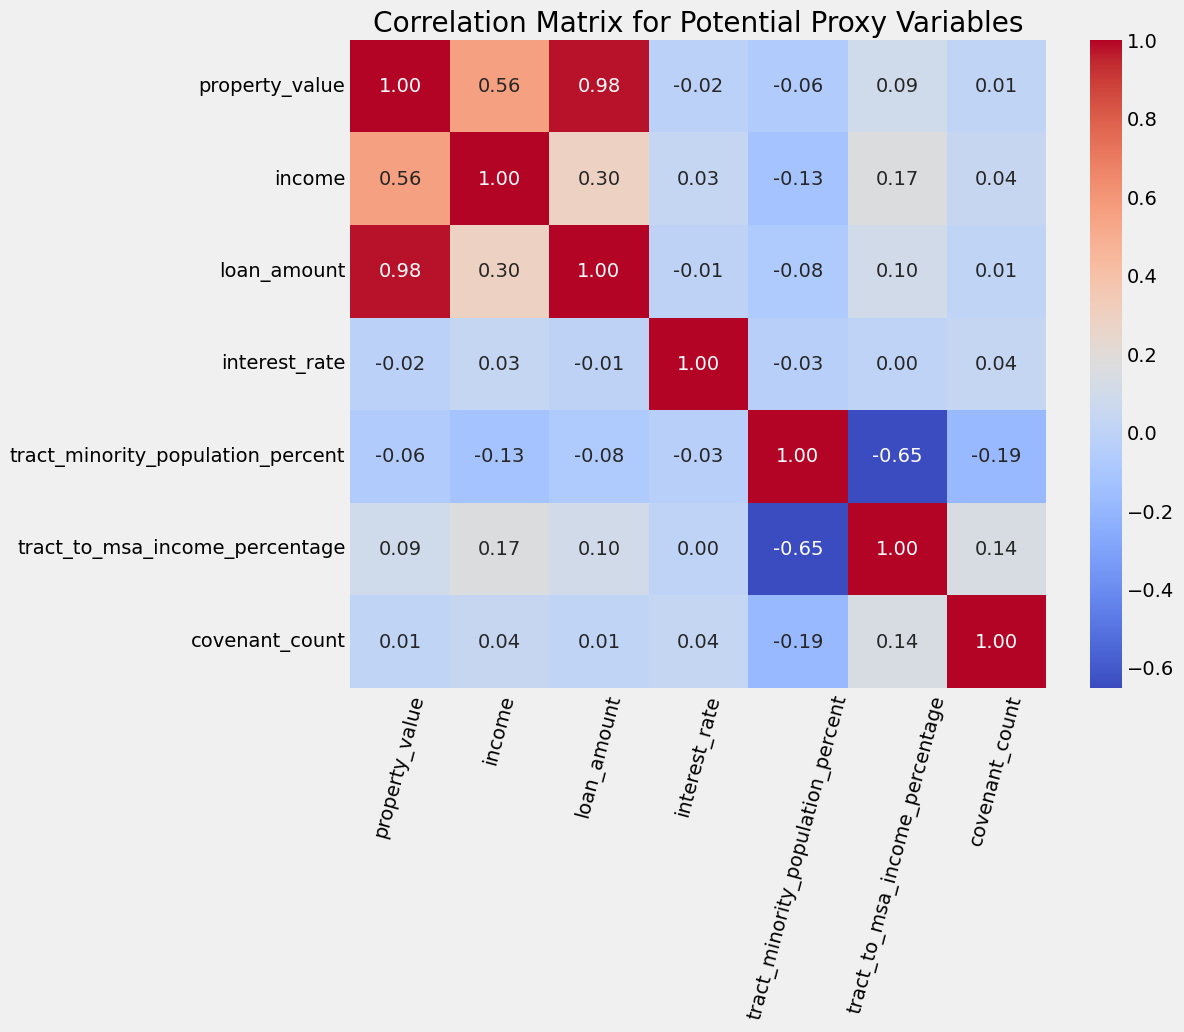

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot = True, cmap= 'coolwarm', fmt ='.2f')
plt.title('Correlation Matrix for Potential Proxy Variables')
plt.xticks(rotation=75)

Looking at the heatmap, it makes the correlation table easier to see. The darkest strong pattern is between property_value and loan_amount, while the relationship between covenant_count and the other variables looks much weaker.

In [16]:
proxy_summary = df_hennepin.groupby('has_covenant')[['tract_minority_population_percent', 'tract_to_msa_income_percentage', 'property_value', 'income']].agg(['mean', 'median'])
display(proxy_summary)

tract_minority_population_percent         \
                                          mean median   
has_covenant                                            
False                                34.818958  27.65   
True                                 30.374508  23.40   

             tract_to_msa_income_percentage         property_value            \
                                       mean  median           mean    median   
has_covenant                                                                   
False                            110.348786  112.10  501293.300145  365000.0   
True                             110.928425   99.91  487349.429698  355000.0   

                  income         
                    mean median  
has_covenant                     
False         151.126010  113.0  
True          163.173426  111.0

Looking at the summary by whether a tract had a covenant or not, it shows that non-covenanted areas have a higher mean and median tract minority population percent. It also shows that covenanted areas have a slightly higher mean income, but the median income and the tract-to-MSA income values are fairly close between the two groups.

Text(0, 0.5, 'Covenant Count')

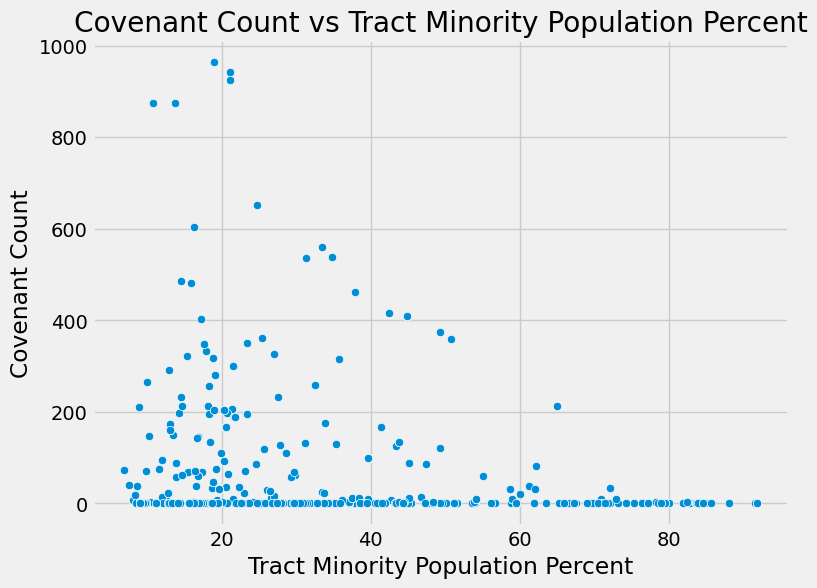

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_hennepin, x = 'tract_minority_population_percent', y ='covenant_count')
plt.title('Covenant Count vs Tract Minority Population Percent')
plt.xlabel('Tract Minority Population Percent')
plt.ylabel('Covenant Count')

Looking at the scatterplot of tract minority population percent and covenant count, it shows that the points are spread out and do not form a strong straight pattern. Still, the higher covenant counts appear more often at lower to middle minority population percentages than at the highest percentages.

Text(0, 0.5, 'Covenant Count')

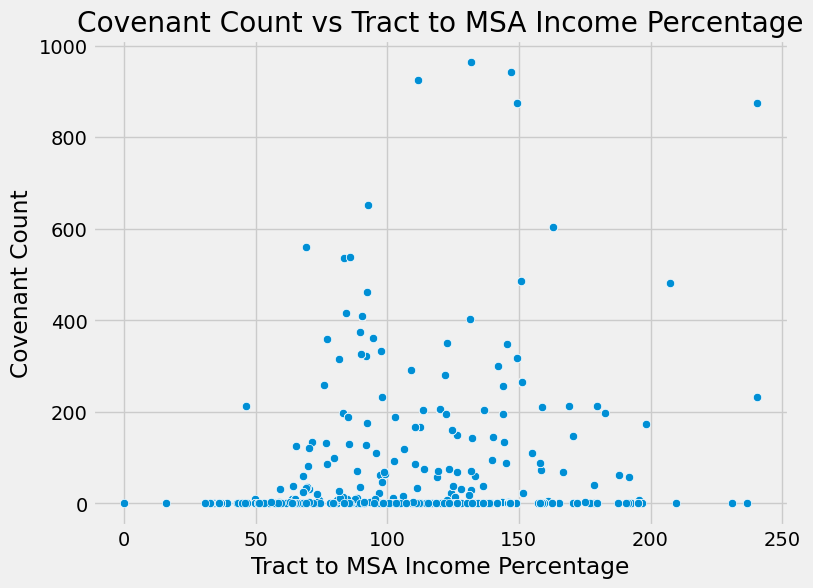

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_hennepin, x='tract_to_msa_income_percentage', y='covenant_count')
plt.title('Covenant Count vs Tract to MSA Income Percentage')
plt.xlabel('Tract to MSA Income Percentage')
plt.ylabel('Covenant Count')

Looking at the scatterplot of tract to MSA income percentage and covenant count, it shows that the points are also widely spread out. There are some higher covenant counts in middle and higher tract to MSA income ranges, but the pattern is not very strong or clean.

**Summary**:
In this analysis, some of the neighborhood variables could work as proxy variables, but the relationships are not very strong. The clearest pattern is that tracts with a higher minority population percent tend to have lower tract to MSA income percentages, which shows a link between race and neighborhood income. Covenant count also has a small negative relationship with minority population percent and a small positive relationship with tract to MSA income percentage. The group summary supports this by showing that covenanted areas have a lower minority population percent and a slightly higher mean income. Overall, this suggests that neighborhood makeup and income may carry some signs of older housing discrimination, but covenant count by itself does not strongly explain the modern variables in a simple one-to-one way.

### Lending Patterns in Historically Covenanted vs. Non-Covenanted Areas

In [19]:
lending_comparison = df_hennepin.groupby('has_covenant')[['loan_amount', 'property_value', 'income', 'interest_rate', 'was_approved']].agg(['count', 'mean', 'median'])
display(lending_comparison)

loan_amount                          property_value  \
                   count           mean    median          count   
has_covenant                                                       
False              11500  382471.304348  315000.0           9642   
True               11169  383043.692363  305000.0           9381   

                                      income                    interest_rate  \
                       mean    median  count        mean median         count   
has_covenant                                                                    
False         501293.300145  365000.0   9904  151.126010  113.0          9089   
True          487349.429698  355000.0   9641  163.173426  111.0          8980   

                               was_approved                   
                  mean  median        count      mean median  
has_covenant                                                  
False         6.524952  6.6250        11500  0.649826    1.0  
True          6.610344  6.7325        11169  0.671054    1.0

Looking at the lending summary by whether a tract had a covenant or not, it shows that the two groups are fairly close in many ways. Areas with a covenant have a slightly higher approval rate and a slightly higher average interest rate, while areas without a covenant have a slightly higher median loan amount and median property value.

(0.0, 1.0)

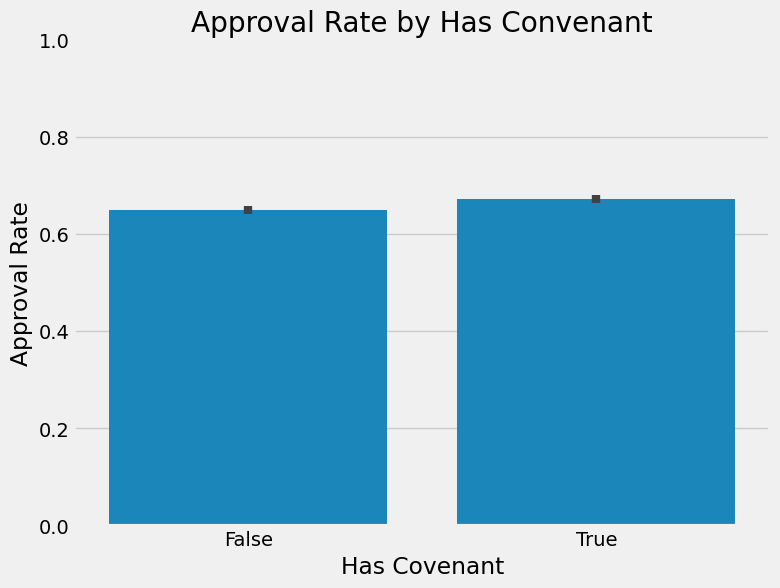

In [20]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df_hennepin, x='has_covenant', y='was_approved')
plt.title('Approval Rate by Has Convenant')
plt.xlabel('Has Covenant')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)

Looking at the bar chart for approval rate by covenant status, it shows that the group with a historical covenant has a somewhat higher approval rate than the group without one. The gap is not large, but it is visible in the chart.

Text(0, 0.5, 'Interest Rate')

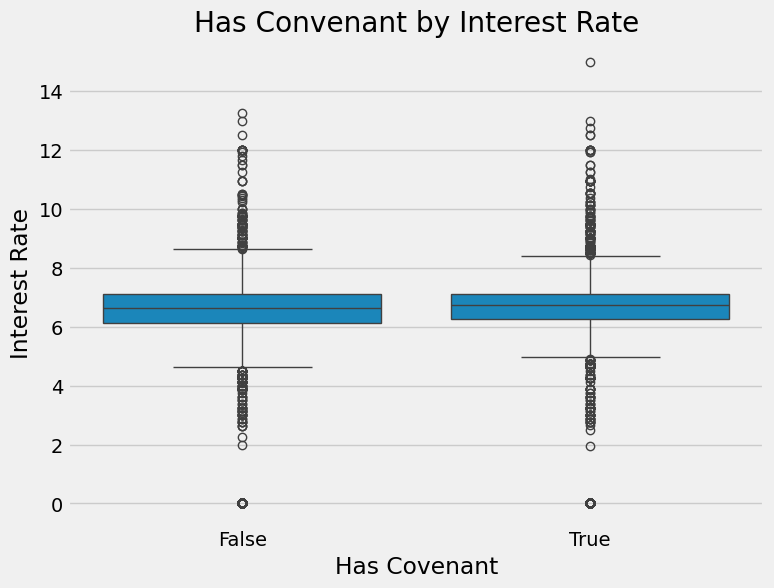

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(data= df_hennepin, x='has_covenant', y='interest_rate')
plt.title('Has Convenant by Interest Rate')
plt.xlabel('Has Covenant')
plt.ylabel('Interest Rate')

Looking at the boxplot for interest rate by covenant status, it shows that the two groups have very similar interest rate ranges. Still, the group with a covenant looks a little higher in the middle, which matches the summary table.

Text(0, 0.5, 'Loan Amount')

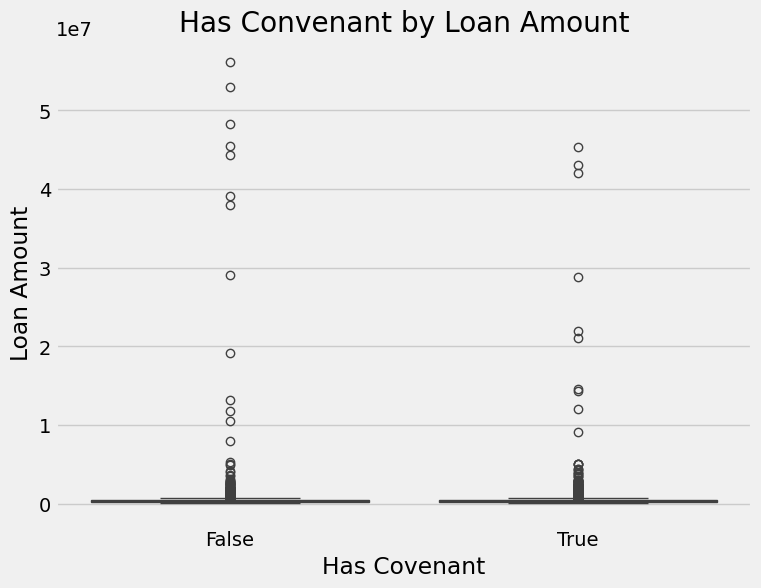

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_hennepin, x ='has_covenant', y='loan_amount')
plt.title('Has Convenant by Loan Amount')
plt.xlabel('Has Covenant')
plt.ylabel('Loan Amount')

Looking at the boxplot for loan amount by covenant status, it shows that the two groups are very similar in the middle, but both have many large outliers. The non-covenanted group looks a little higher in the median loan amount, even though the averages are very close.

**Summary**: In this analysis, lending patterns in covenanted and non-covenanted areas are similar in some ways but not the same in all ways. Areas with a historical covenant have a slightly higher approval rate, a slightly higher average interest rate, and a slightly higher average income. At the same time, areas without a covenant have a slightly higher median loan amount and median property value. These differences are real in the summary, but most of them are not very large, and the graphs show a lot of overlap between the two groups. Overall, this suggests that covenant history may still connect to modern lending patterns, but the effect does not look large or simple in this first comparison.

### Overall Initial Analysis:
In this initial analysis, the results show that historical covenant patterns may still connect to modern housing and lending data, but the patterns are not always strong or simple. Property values show some differences by covenant history, especially when looking at covenant density, but there is also a lot of overlap and many large outliers. Mortgage approval patterns seem to show stronger differences by race than by covenant history alone, which means covenant status by itself does not explain approval outcomes very well in this first look. The proxy variable analysis also suggests that neighborhood race and income may carry signs of older discrimination, even if covenant count does not have a strong one-to-one relationship with every modern measure. When lending patterns are compared between covenanted and non-covenanted areas, the differences are present but fairly small. Overall, this first section suggests that the history of discrimination may still appear in the data, but the story is mixed and needs deeper analysis to separate data bias from algorithmic bias.

## Data Bias

### Property Values in Areas With and Without Historical Covenants

In [23]:
property_bias_summary = df_hennepin.groupby('has_covenant')[['property_value']].agg(['count', 'mean', 'median', 'std'])
display(property_bias_summary)

property_value                                       
                      count           mean    median           std
has_covenant                                                      
False                  9642  501293.300145  365000.0  2.105706e+06
True                   9381  487349.429698  355000.0  1.020242e+06

Looking at the property value summary by covenant status, it shows that areas without a historical covenant have a slightly higher mean and median property value than areas with a covenant. The difference is not huge, but it does suggest that home values are a little higher in non-covenanted areas.

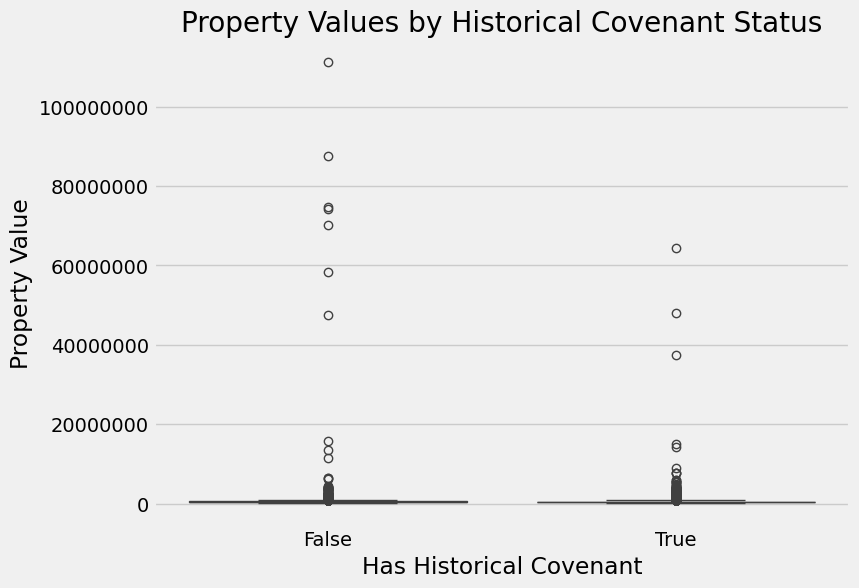

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_hennepin, x='has_covenant', y='property_value')
plt.title('Property Values by Historical Covenant Status')
plt.xlabel('Has Historical Covenant')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')

Looking at the boxplot for property values by covenant status, it shows that both groups have many very large outliers. It also shows that the middle of the non-covenanted group is a little higher than the covenanted group, even though the two groups overlap a lot.

In [25]:
property_density_bias = df_hennepin.groupby('covenant_density', dropna=False)['property_value'].agg(['count', 'mean', 'median', 'std'])
display(property_density_bias)

,count,mean,median,std
covenant_density,,,,
High (101-200),1438,547739.916551,375000.0,1.749168e+06
Low (1-50),3779,418831.701508,325000.0,3.404951e+05
Medium (51-100),1504,567187.500000,365000.0,1.682592e+06
Very High (>200),2660,506902.255639,385000.0,4.906733e+05
NaN,9642,501293.300145,365000.0,2.105706e+06


Looking at the property value summary by covenant density, it shows that the Low (1-50) group has the lowest median property value at $325,000. The Very High (>200) group has the highest median at $385,000, while the other groups fall in between.

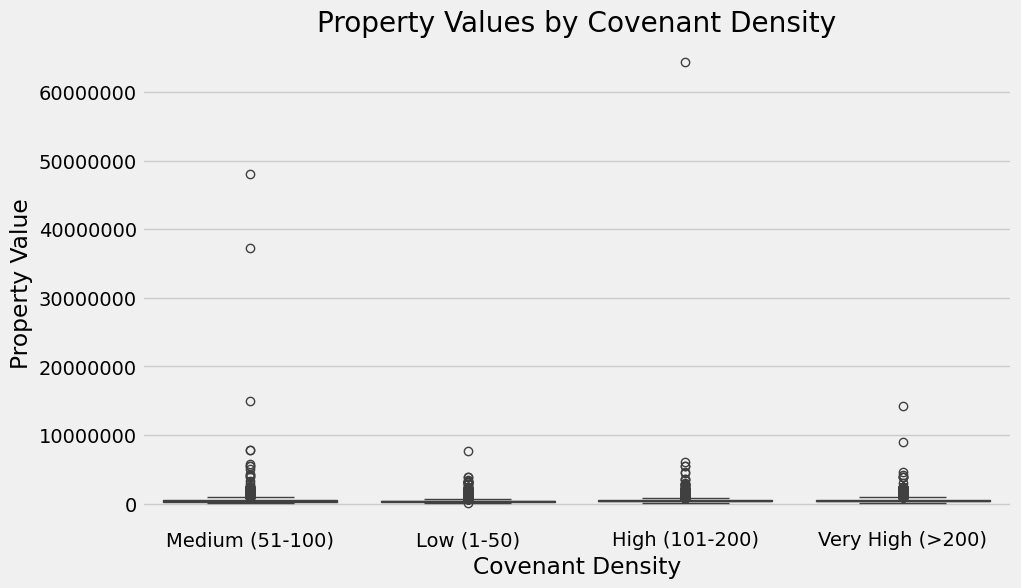

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hennepin, x='covenant_density', y='property_value')
plt.title('Property Values by Covenant Density')
plt.xlabel('Covenant Density')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')

Looking at the boxplot for property values by covenant density, it shows that the groups have a lot of overlap, but they are not all centered in the same place. The Low (1-50) group looks lower than the others, and all groups have some large outliers that stretch the graph upward.

**Summary**:
In this analysis, property values do differ some based on covenant history, which supports the idea of data bias in the modern data. Areas without a historical covenant have a slightly higher median property value than areas with a covenant, and the density groups also show differences, with the Low (1-50) group standing out as the lowest. At the same time, the pattern is not perfectly straight, because the Very High (>200) group has the highest median and the other groups are fairly close. The graphs also show many large outliers, so the averages can be pulled upward by a small number of very expensive homes. Overall, this suggests that historical covenant patterns may still connect to present-day property values, but the effect is uneven and should be read with care.

### Neighborhood Demographic Characteristics

In [27]:
demographic_summary = df_hennepin.groupby('has_covenant')[['tract_minority_population_percent']].agg(['count', 'mean', 'median', 'std'])
display(demographic_summary)

tract_minority_population_percent                             
                                         count       mean median        std
has_covenant                                                               
False                                    11500  34.818958  27.65  21.322465
True                                     11169  30.374508  23.40  18.493516

Looking at the tract minority population summary by covenant status, it shows that areas without a historical covenant have a higher mean and median minority population percent than areas with a covenant. This suggests that non-covenanted areas in this data are more minority-populated on average.

Text(0, 0.5, 'Tract Minority Population Percent')

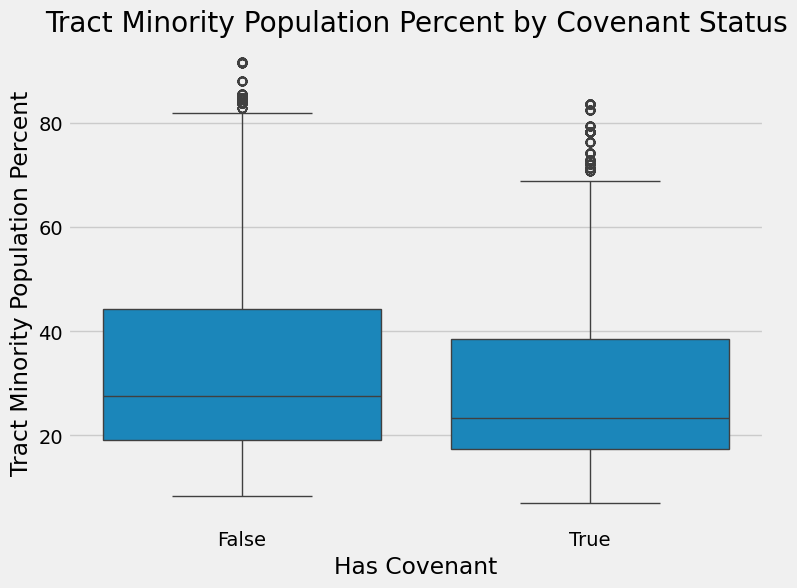

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_hennepin, x='has_covenant', y='tract_minority_population_percent')
plt.title('Tract Minority Population Percent by Covenant Status')
plt.xlabel('Has Covenant')
plt.ylabel('Tract Minority Population Percent')

Looking at the boxplot for tract minority population percent by covenant status, it shows that the non-covenanted group is centered higher than the covenanted group. The two groups still overlap, but the non-covenanted tracts generally have higher minority population percentages.

In [29]:
demographic_density_summary = df_hennepin.groupby('covenant_density', dropna=False)['tract_minority_population_percent'].agg(['count', 'mean', 'median', 'std'])
display(demographic_density_summary)

,count,mean,median,std
covenant_density,,,,
High (101-200),1720,24.150360,21.62,9.700537
Low (1-50),4537,37.501120,33.40,22.326304
Medium (51-100),1772,26.929069,20.80,15.606641
Very High (>200),3140,25.431010,19.08,13.482364
NaN,11500,34.818958,27.65,21.322465


Looking at the tract minority population summary by covenant density, it shows that the Low (1-50) group has the highest mean and median minority population percent. The Very High (>200) group has one of the lowest medians, which suggests that the heaviest covenant areas tend to have lower minority population percentages in the modern data.

Text(0, 0.5, 'Tract Minority Population Percent')

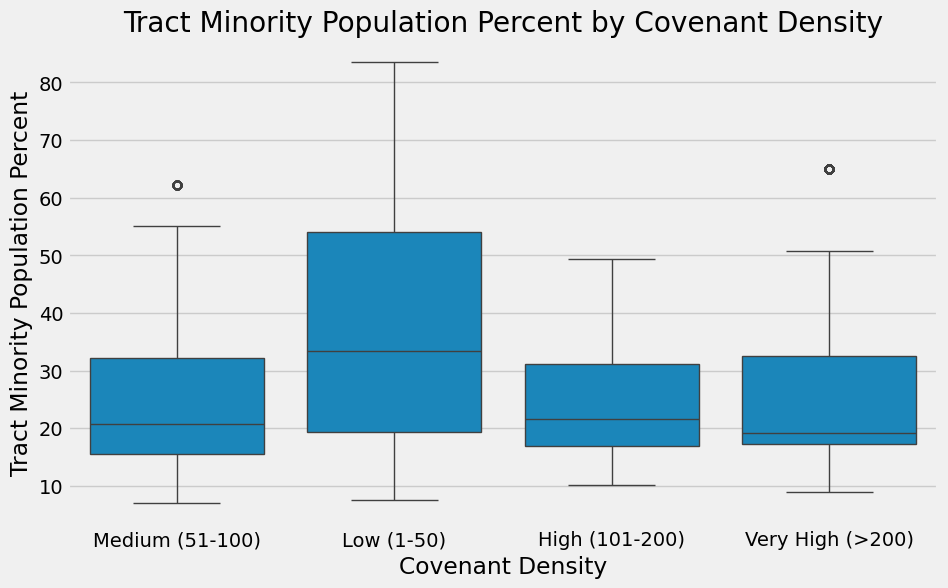

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hennepin, x='covenant_density', y='tract_minority_population_percent')
plt.title('Tract Minority Population Percent by Covenant Density')
plt.xlabel('Covenant Density')
plt.ylabel('Tract Minority Population Percent')

Looking at the boxplot for tract minority population percent by covenant density, it shows that the Low (1-50) group sits higher than the other covenant density groups. The other groups are lower and closer together, especially High (101-200) and Very High (>200).

**Summary**: 
In this analysis, neighborhood demographic patterns do seem tied to historical covenant history. Areas without a historical covenant have higher minority population percentages than areas with a covenant, and the covenant density groups show that the heaviest covenant areas tend to have lower minority population percentages today. The Low (1-50) group stands out because it has the highest minority population levels, while the denser covenant groups are lower. This supports the idea that old housing discrimination may still be visible in the makeup of neighborhoods now. Overall, the results suggest that covenant history is connected to present-day demographic patterns, which is a sign of data bias in the modern data.

### Neighborhood Economic Characteristics

In [31]:
economic_summary = df_hennepin.groupby('has_covenant')[['tract_to_msa_income_percentage', 'income']].agg(['count', 'mean', 'median', 'std'])
display(economic_summary)

tract_to_msa_income_percentage                                 \
                                      count        mean  median        std   
has_covenant                                                                 
False                                 11500  110.348786  112.10  42.353395   
True                                  11169  110.928425   99.91  40.881539   

             income                                 
              count        mean median         std  
has_covenant                                        
False          9904  151.126010  113.0  190.862021  
True           9641  163.173426  111.0  432.811439

Looking at the economic summary by covenant status, it shows that the two groups are fairly close in median values. Areas without a covenant have a higher median tract-to-MSA income percentage, while applicant median income is almost the same in both groups.

Text(0, 0.5, 'Tract to MSA Income Percentage')

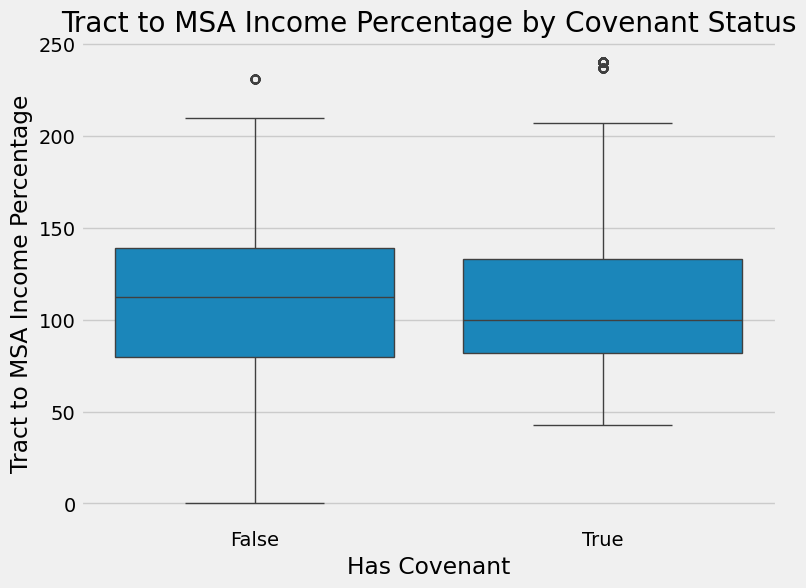

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_hennepin, x='has_covenant', y='tract_to_msa_income_percentage')
plt.title('Tract to MSA Income Percentage by Covenant Status')
plt.xlabel('Has Covenant')
plt.ylabel('Tract to MSA Income Percentage')

Looking at the boxplot for tract to MSA income percentage by covenant status, it shows that the two groups overlap a lot. The non-covenanted group looks a little higher in the middle, but the difference is not very large.

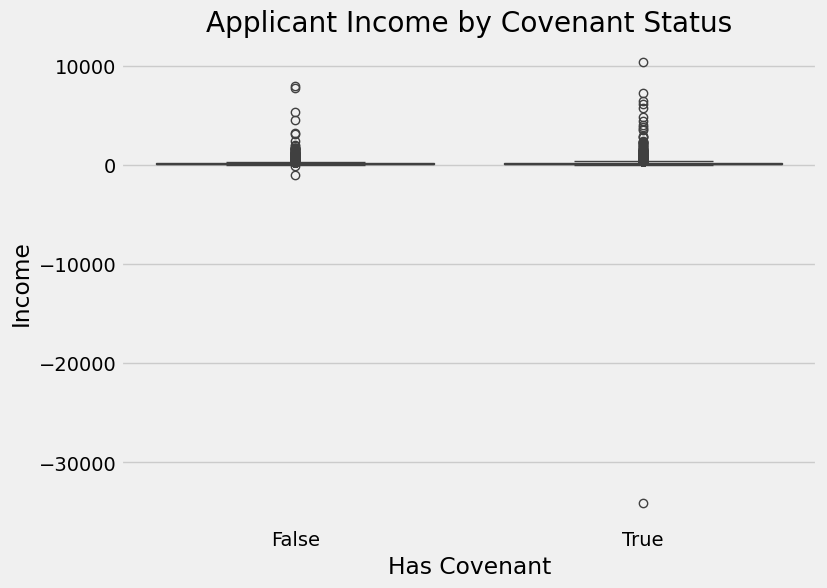

In [33]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_hennepin, x='has_covenant', y='income')
plt.title('Applicant Income by Covenant Status')
plt.xlabel('Has Covenant')
plt.ylabel('Income')
plt.ticklabel_format(style='plain', axis='y')

Looking at the boxplot for applicant income by covenant status, it shows that most of the data is packed near the bottom and there are several large outliers. The two groups look very similar in the middle, so there is not a strong clear split in applicant income just from covenant status alone.

In [34]:
economic_density_summary = df_hennepin.groupby('covenant_density', dropna=False)[['tract_to_msa_income_percentage', 'income']].agg(['count', 'mean', 'median'])
display(economic_density_summary)

tract_to_msa_income_percentage                     income  \
                                          count        mean  median  count   
covenant_density                                                             
High (101-200)                             1720  116.914163  110.60   1482   
Low (1-50)                                 4537   99.387064   88.30   3949   
Medium (51-100)                            1772  112.761580  102.45   1526   
Very High (>200)                           3140  123.291271  119.95   2684   
NaN                                       11500  110.348786  112.10   9904   

                                     
                        mean median  
covenant_density                     
High (101-200)    181.273954  117.0  
Low (1-50)        139.971892  100.0  
Medium (51-100)   168.160550  112.0  
Very High (>200)  184.480253  128.0  
NaN               151.126010  113.0

Looking at the economic summary by covenant density, it shows that the Low (1-50) group has the lowest median tract to MSA income percentage and the lowest median applicant income. The Very High (>200) group has the highest median values for both measures, while High (101-200) and Medium (51-100) fall in between.

**Summary**: 
In this analysis, the neighborhood economic patterns do show some differences tied to covenant history, but the pattern is mixed. When the data is split into only covenant versus no covenant, the two groups look pretty close, with non-covenanted areas having a slightly higher median tract to MSA income percentage and nearly the same median applicant income. But when the data is split by covenant density, the pattern becomes clearer. The Low (1-50) group has the lowest neighborhood income and applicant income levels, while the denser covenant groups, especially Very High (>200), are higher. This suggests that historical covenant patterns may still connect to modern economic conditions, but the effect shows up more clearly by density than by the simple yes or no covenant split.

### Patterns of Wealth and Investment

In [35]:
wealth_summary = df_hennepin.groupby('has_covenant')[['property_value', 'income', 'loan_amount']].agg(['mean', 'median'])
display(wealth_summary)

property_value                income           loan_amount  \
                       mean    median        mean median           mean   
has_covenant                                                              
False         501293.300145  365000.0  151.126010  113.0  382471.304348   
True          487349.429698  355000.0  163.173426  111.0  383043.692363   

                        
                median  
has_covenant            
False         315000.0  
True          305000.0

Looking at the wealth summary by covenant status, it shows that areas without a covenant have a slightly higher median property value and median loan amount. Applicant median income is almost the same in both groups, even though the average income is a little higher in the covenanted group.

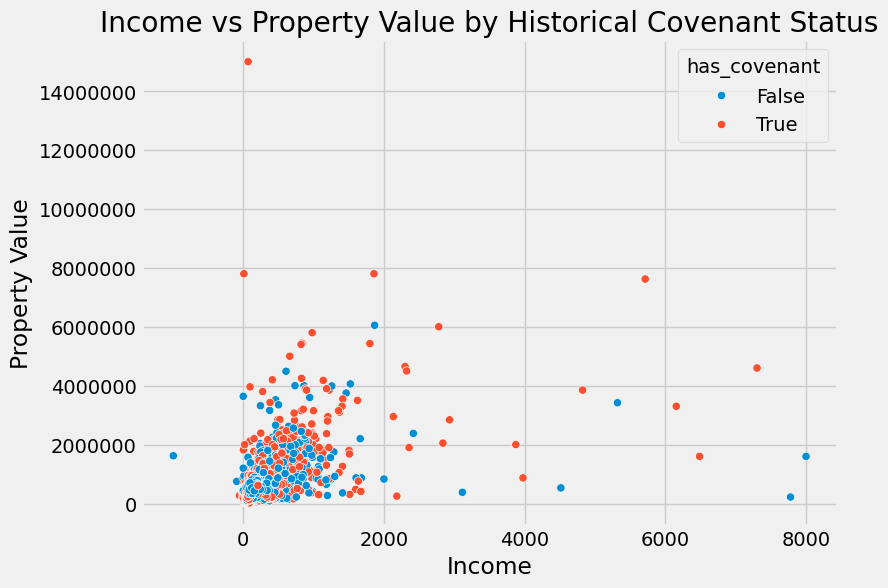

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_hennepin, x='income', y='property_value', hue='has_covenant')
plt.title('Income vs Property Value by Historical Covenant Status')
plt.xlabel('Income')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')

Looking at the scatterplot of income and property value, it shows that higher income often goes with higher property value, but the points are spread out a lot. The two covenant groups overlap heavily, so there is not a sharp split between them in this relationship.

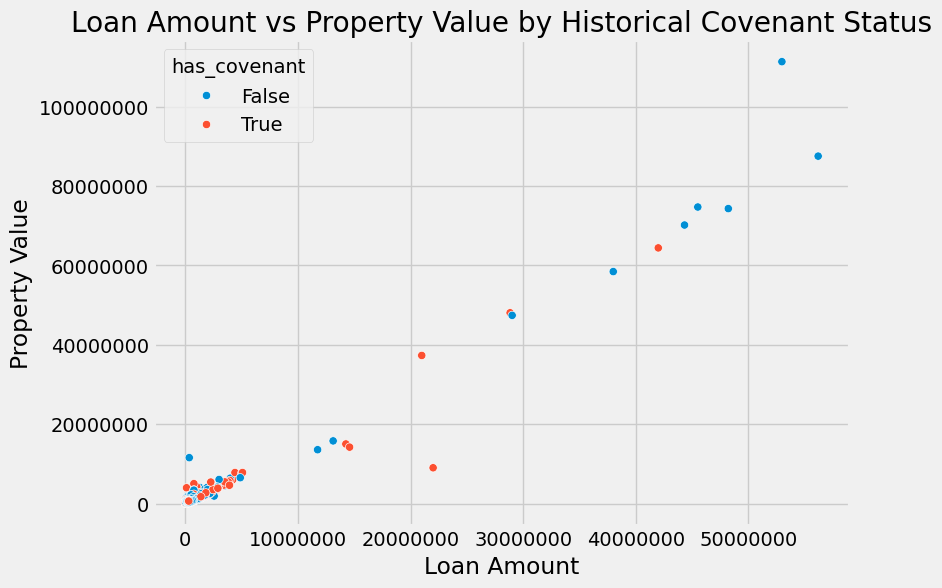

In [37]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_hennepin, x='loan_amount',  y='property_value', hue='has_covenant')
plt.title('Loan Amount vs Property Value by Historical Covenant Status')
plt.xlabel('Loan Amount')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='both')

Looking at the scatterplot of loan amount and property value, it shows a strong upward pattern, which means larger loans usually go with higher property values. The two covenant groups again overlap a lot, so both groups follow a similar general pattern.

**Summary**: In this analysis, the patterns of wealth and investment show some small differences by covenant status, but not a clean divide. Non-covenanted areas have a slightly higher median property value and median loan amount, while applicant income is very similar in the middle of both groups. The scatterplots also show that both groups follow similar patterns, especially for loan amount and property value, where the relationship is strong in both cases. Overall, this suggests that wealth and investment patterns may still reflect some effects of past discrimination, but the split between covenanted and non-covenanted areas is not large or simple in this first look.

## Race Bias

In [38]:
race_property_summary = df_hennepin.groupby('derived_race')[['property_value', 'income', 'loan_amount']].agg(['count', 'mean', 'median'])
display(race_property_summary)

property_value                 \
                                                   count           mean   
derived_race                                                              
2 or more minority races                              30  312000.000000   
American Indian or Alaska Native                     118  316779.661017   
Asian                                               1296  460154.320988   
Black or African American                           1455  340615.120275   
Joint                                                595  471823.529412   
Native Hawaiian or Other Pacific Islander             17  322058.823529   
Race Not Available                                  4644  634493.970715   
White                                              10868  463176.297387   

                                                    income                     \
                                             median  count        mean median   
derived_race                                                                    
2 or more minority races                   305000.0     42   97.142857   76.0   
American Indian or Alaska Native           305000.0    147  113.285714   85.0   
Asian                                      375000.0   1619  153.657196  118.0   
Black or African American                  315000.0   1744  109.094610   85.0   
Joint                                      385000.0    681  171.600587  143.0   
Native Hawaiian or Other Pacific Islander  285000.0     17   86.647059   70.0   
Race Not Available                         375000.0   2650  170.995472  110.0   
White                                      365000.0  12645  161.223488  115.0   

                                          loan_amount                           
                                                count           mean    median  
derived_race                                                                    
2 or more minority races                           42  268095.238095  285000.0  
American Indian or Alaska Native                  147  255816.326531  265000.0  
Asian                                            1642  365779.537150  325000.0  
Black or African American                        1760  277170.454545  275000.0  
Joint                                             683  381793.557833  335000.0  
Native Hawaiian or Other Pacific Islander          18  222777.777778  225000.0  
Race Not Available                               5610  483905.525847  315000.0  
White                                           12767  357159.473643  305000.0

Looking at the summary by race, it shows that property values, income, and loan amounts are not the same across race groups. White, Asian, and Joint applicants tend to have higher median property values and incomes, while Black or African American, American Indian or Alaska Native, and some smaller race groups tend to have lower median values.

In [39]:
race_neighborhood_summary = df_hennepin.groupby('derived_race')[['tract_minority_population_percent', 'tract_to_msa_income_percentage', 'covenant_count']].agg(['mean', 'median'])
display(race_neighborhood_summary)

tract_minority_population_percent  \
                                                                       mean   
derived_race                                                                  
2 or more minority races                                          47.044762   
American Indian or Alaska Native                                  40.456939   
Asian                                                             35.378946   
Black or African American                                         48.876062   
Joint                                                             33.006003   
Native Hawaiian or Other Pacific Islander                         36.956111   
Race Not Available                                                32.948677   
White                                                             29.731602   

                                                   \
                                           median   
derived_race                                        
2 or more minority races                   41.970   
American Indian or Alaska Native           35.290   
Asian                                      29.710   
Black or African American                  48.390   
Joint                                      26.530   
Native Hawaiian or Other Pacific Islander  31.575   
Race Not Available                         25.860   
White                                      23.450   

                                          tract_to_msa_income_percentage  \
                                                                    mean   
derived_race                                                               
2 or more minority races                                       90.810000   
American Indian or Alaska Native                               94.901361   
Asian                                                         118.475463   
Black or African American                                      88.229193   
Joint                                                         109.198023   
Native Hawaiian or Other Pacific Islander                      89.982778   
Race Not Available                                            110.417383   
White                                                         113.162258   

                                                   covenant_count         
                                            median           mean median  
derived_race                                                              
2 or more minority races                    79.425      55.023810    0.0  
American Indian or Alaska Native            86.950      76.061224    1.0  
Asian                                      121.350      42.023143    0.0  
Black or African American                   83.530      32.919886    0.0  
Joint                                      102.060      81.396779    1.0  
Native Hawaiian or Other Pacific Islander   88.995      79.166667    3.5  
Race Not Available                         106.890      79.856328    0.0  
White                                      110.400      87.065951    1.0

Looking at the neighborhood summary by race, it shows that race groups are connected to different neighborhood conditions. Black or African American applicants have the highest tract minority population percent and one of the lowest tract to MSA income percentages, while White and Asian applicants tend to be in tracts with lower minority population percentages and higher tract to MSA income levels.

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Race Not Available'),
  Text(1, 0, 'White'),
  Text(2, 0, 'Asian'),
  Text(3, 0, 'Joint'),
  Text(4, 0, 'Black or African American'),
  Text(5, 0, 'American Indian or Alaska Native'),
  Text(6, 0, 'Native Hawaiian or Other Pacific Islander'),
  Text(7, 0, '2 or more minority races')])

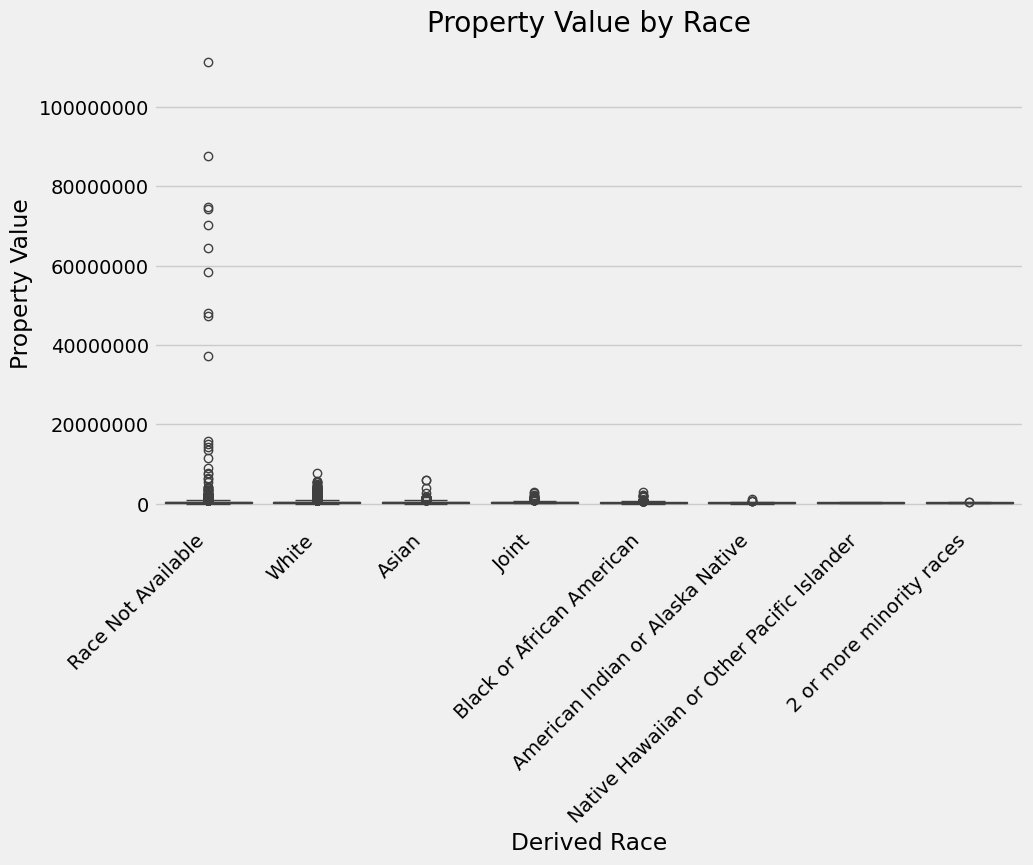

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hennepin, x='derived_race', y='property_value')
plt.title('Property Value by Race')
plt.xlabel('Derived Race')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')

Looking at the boxplot for property value by race, it shows that the race groups are not centered at the same level. Some groups, such as White, Asian, and Joint, tend to sit higher, while Black or African American and American Indian or Alaska Native tend to be lower.

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Race Not Available'),
  Text(1, 0, 'White'),
  Text(2, 0, 'Asian'),
  Text(3, 0, 'Joint'),
  Text(4, 0, 'Black or African American'),
  Text(5, 0, 'American Indian or Alaska Native'),
  Text(6, 0, 'Native Hawaiian or Other Pacific Islander'),
  Text(7, 0, '2 or more minority races')])

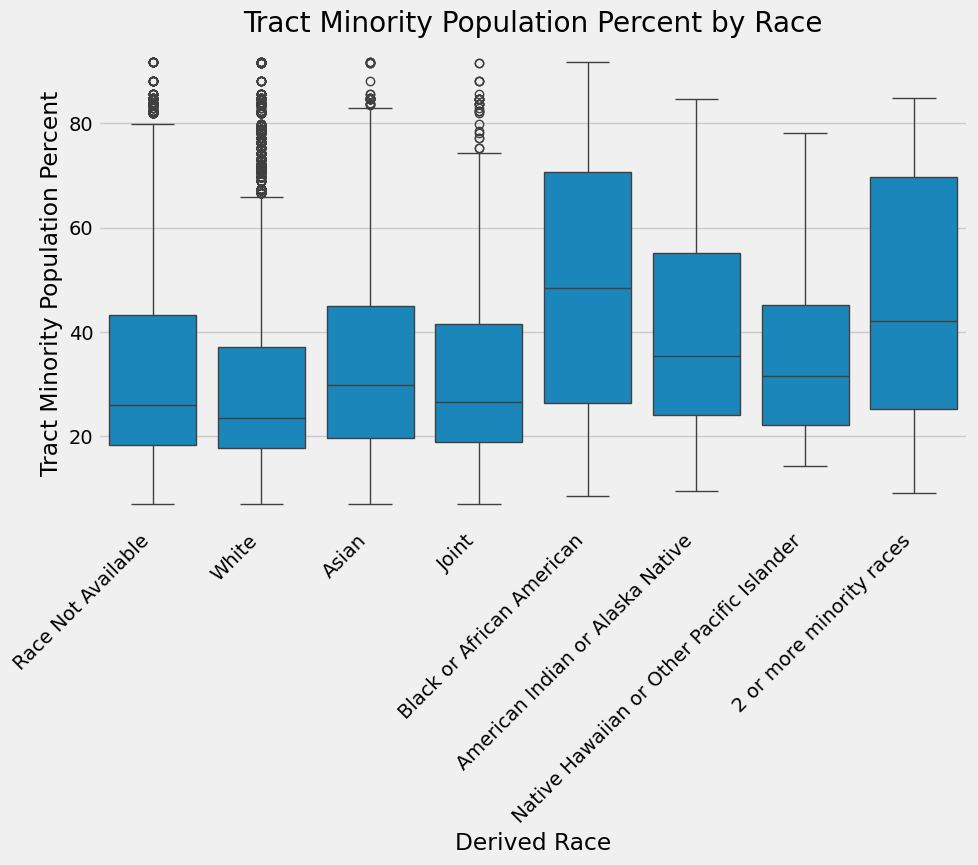

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hennepin, x='derived_race', y='tract_minority_population_percent')
plt.title('Tract Minority Population Percent by Race')
plt.xlabel('Derived Race')
plt.ylabel('Tract Minority Population Percent')
plt.xticks(rotation=45, ha='right')

Looking at the boxplot for tract minority population percent by race, it shows clear differences between groups. Black or African American applicants are centered in tracts with higher minority population percentages, while White and Joint applicants tend to be in tracts with lower percentages.

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Race Not Available'),
  Text(1, 0, 'White'),
  Text(2, 0, 'Asian'),
  Text(3, 0, 'Joint'),
  Text(4, 0, 'Black or African American'),
  Text(5, 0, 'American Indian or Alaska Native'),
  Text(6, 0, 'Native Hawaiian or Other Pacific Islander'),
  Text(7, 0, '2 or more minority races')])

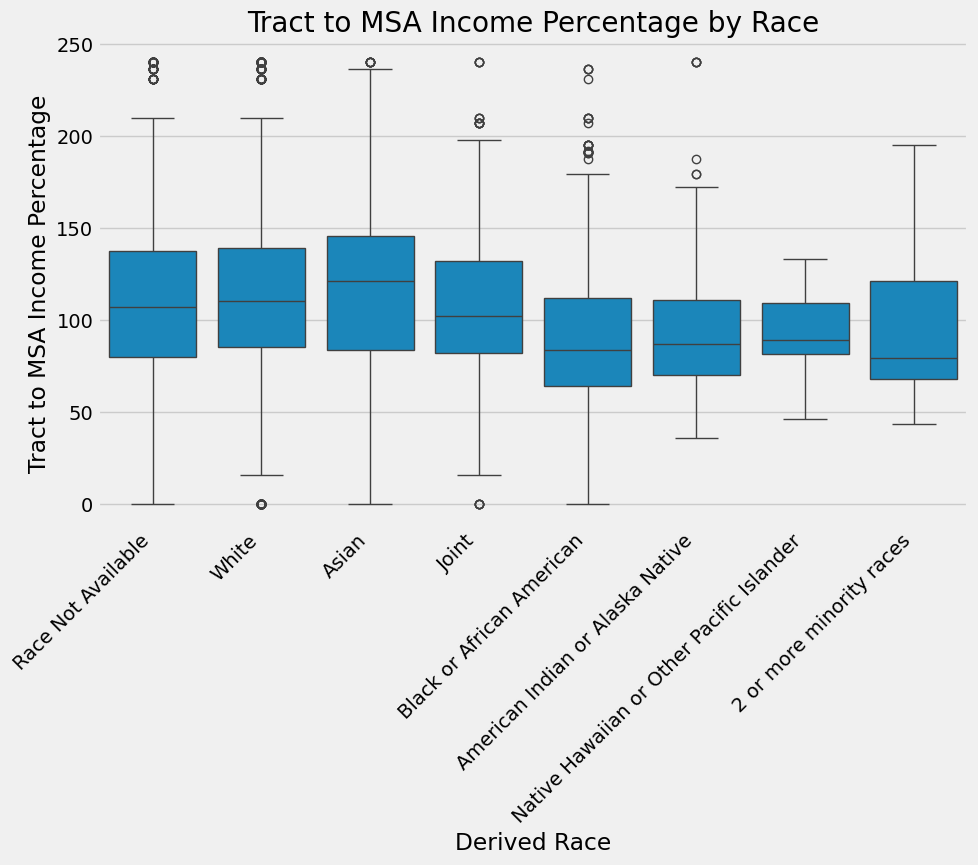

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hennepin, x='derived_race', y='tract_to_msa_income_percentage')
plt.title('Tract to MSA Income Percentage by Race')
plt.xlabel('Derived Race')
plt.ylabel('Tract to MSA Income Percentage')
plt.xticks(rotation=45, ha='right')

Looking at the boxplot for tract to MSA income percentage by race, it shows that some race groups are tied to higher income tracts and others are tied to lower income tracts. Asian, White, and Joint applicants tend to be higher, while Black or African American and some other minority groups tend to be lower.

In [43]:
race_covenant_summary = pd.crosstab(df_hennepin['derived_race'], df_hennepin['has_covenant'], normalize='index')
display(race_covenant_summary)

has_covenant,False,True
derived_race,,
2 or more minority races,0.571429,0.428571
American Indian or Alaska Native,0.462585,0.537415
Asian,0.668697,0.331303
Black or African American,0.615341,0.384659
Joint,0.474378,0.525622
Native Hawaiian or Other Pacific Islander,0.333333,0.666667
Race Not Available,0.506774,0.493226
White,0.474191,0.525809


Looking at the crosstab by race and covenant status, it shows that the share of people in covenanted and non-covenanted areas is not the same across race groups. White and Joint applicants are a little more likely to be in covenanted areas, while Asian and Black or African American applicants are more likely to be in non-covenanted areas.

In [44]:
race_covenant_property = df_hennepin.groupby(['derived_race', 'has_covenant'])['property_value'].agg(['count', 'mean', 'median'])
display(race_covenant_property)

count           mean  \
derived_race                              has_covenant                         
2 or more minority races                  False            16  306250.000000   
                                          True             14  318571.428571   
American Indian or Alaska Native          False            54  294814.814815   
                                          True             64  335312.500000   
Asian                                     False           850  468458.823529   
                                          True            446  444327.354260   
Black or African American                 False           895  355502.793296   
                                          True            560  316821.428571   
Joint                                     False           280  485285.714286   
                                          True            315  459857.142857   
Native Hawaiian or Other Pacific Islander False             5  407000.000000   
                                          True             12  286666.666667   
Race Not Available                        False          2390  698510.460251   
                                          True           2254  566614.906832   
White                                     False          5152  444279.891304   
                                          True           5716  480208.187544   

                                                          median  
derived_race                              has_covenant            
2 or more minority races                  False         305000.0  
                                          True          305000.0  
American Indian or Alaska Native          False         295000.0  
                                          True          305000.0  
Asian                                     False         390000.0  
                                          True          355000.0  
Black or African American                 False         325000.0  
                                          True          295000.0  
Joint                                     False         400000.0  
                                          True          375000.0  
Native Hawaiian or Other Pacific Islander False         435000.0  
                                          True          285000.0  
Race Not Available                        False         385000.0  
                                          True          375000.0  
White                                     False         375000.0  
                                          True          365000.0

Looking at property values by race and covenant status together, it shows that covenant history does not affect every race group in the same way. For example, White applicants have a slightly higher median property value in covenanted areas, while Asian, Black or African American, Joint, and Race Not Available have lower medians in covenanted areas.

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Race Not Available'),
  Text(1, 0, 'White'),
  Text(2, 0, 'Asian'),
  Text(3, 0, 'Joint'),
  Text(4, 0, 'Black or African American'),
  Text(5, 0, 'American Indian or Alaska Native'),
  Text(6, 0, 'Native Hawaiian or Other Pacific Islander'),
  Text(7, 0, '2 or more minority races')])

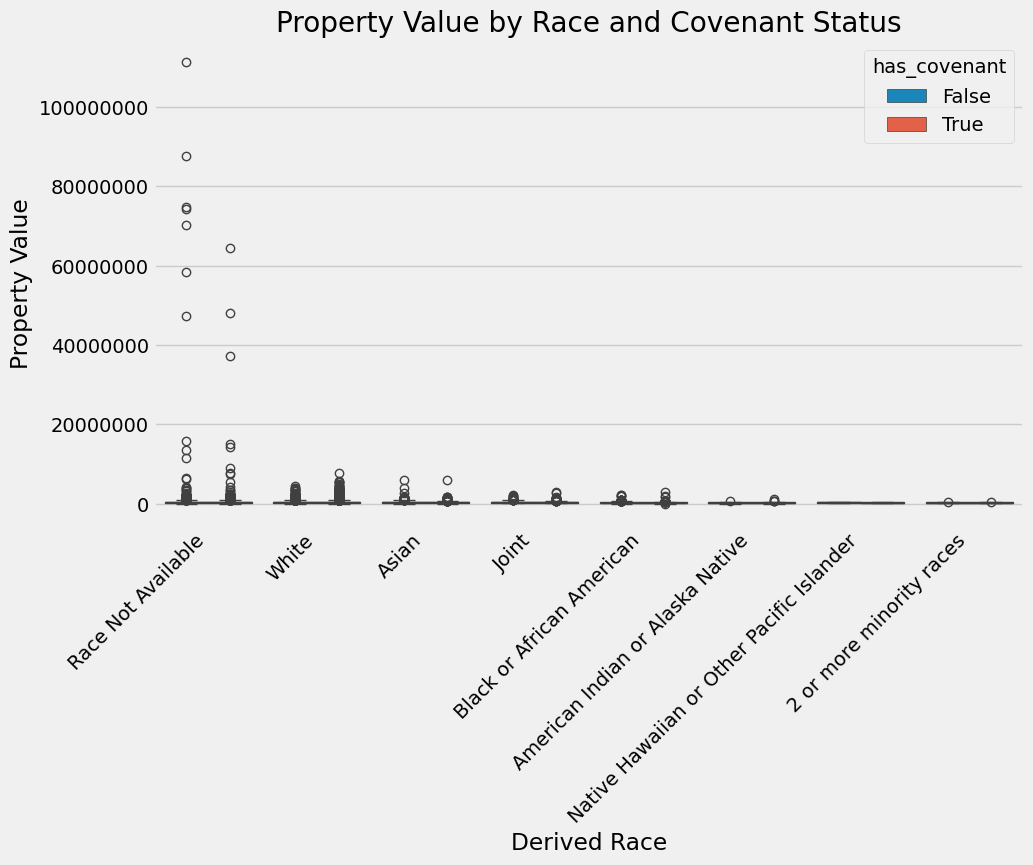

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hennepin, x='derived_race', y='property_value', hue='has_covenant')
plt.title('Property Value by Race and Covenant Status')
plt.xlabel('Derived Race')
plt.ylabel('Property Value')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')

Looking at the boxplot for property value by race and covenant status, it shows that race and covenant history overlap in a more complicated way than a simple one group comparison. The graph suggests that both race and covenant status matter, but the pattern changes depending on which race group is being looked at.

**Summary**:
In this analysis, race shows some of the clearest signs of data bias in the dataset. Property values, incomes, and neighborhood conditions are not spread evenly across race groups. White, Asian, and Joint applicants tend to have higher home values and stronger neighborhood income levels, while Black or African American applicants tend to be linked to lower property values, higher minority population tracts, and lower tract to MSA income percentages. The covenant results also show that race groups are not distributed the same way across covenanted and non-covenanted areas. When race and covenant status are looked at together, the pattern becomes more mixed, which suggests that the effect of covenant history is not the same for every group. Overall, this section supports the idea that historical discrimination may still be built into the modern data through race differences in property values and neighborhood conditions.

### Overall Data Bias:
In this data bias analysis, the results suggest that historical discrimination may still be built into the modern data itself. Property values, neighborhood demographic patterns, and economic conditions all show some differences based on covenant history, even if those differences are not always large. Areas with different levels of covenant history do not look the same in terms of home values, minority population percentages, or income related measures. The race analysis shows some of the clearest differences, with some race groups connected to higher property values and stronger neighborhood income levels, while others are linked to lower values and more disadvantaged neighborhood conditions. These patterns matter because they show that the data going into a modern lending system may already reflect older unequal housing systems. Overall, this section supports the idea that past discrimination still appears in present day housing and mortgage related data, which is a clear sign of data bias.